<a href="https://colab.research.google.com/github/jhonegonzalezq/opti-bio/blob/main/Analisis_Biliometrico_EC15_593.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1g1wJR5QixG-7LhTavm5Egpk34TU1JfuD?usp=sharing)



############################################################################

 Created by: Prof. Valdecy Pereira, D.Sc.
 UFF - Universidade Federal Fluminense (Brazil)
 email:  valdecy.pereira@gmail.com
 pyBibX - A Bibliometric and Scientometric Library
 Example - Scopus

 Citation:
 PEREIRA, V.; BASILIO, M.P.; SANTOS, C.H.T. (2025). PyBibX: A Python Library for Bibliometric and
 Scientometric Analysis Powered with Artificial Intelligence Tools. Data Technologies and Applications.
 Vol. ahead-of-print No. ahead-of-print. doi: https://doi.org/10.1108/DTA-08-2023-0461

############################################################################

In [ ]:
!pip install pybibx
!pip install tabulate

In [ ]:
!pip install --upgrade --force-reinstall numpy==1.26.4 pandas

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 1.4 MB/s eta 0:00:00
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.2/509.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.8/347.8 kB 13.6 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: tzdata
    Found existing installation: tzdata 2025.2
    Uninstalling tzdata-2025.2:
      Successfully uninstalled tzdata-2025.2
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.

In [ ]:
!pip install bibtexparser

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for bibtexparser: filename=bibtexparser-1.4.3-py3-none-any.whl size=43549 sha256=076c27bd79cb4a0d6c34b5f267c9aeb3a2891382136539942b931547ee4bebcc
  Stored in directory: /root/.cache/pip/wheels/1f/7d/e9/1ff2509f13767a55df1279744adfb757f4ab94b2cbe761f56a
Successfully built bibtexparser


In [ ]:
# Dowload .bib file
!wget  scopus.bib https://github.com/jorgeiv500/opti-bio/raw/main/scopus593.bib # se puede cambiar por scopus_1, scopus_2, scopus_3
#!wget https://github.com/Valdecy/pyBibX/raw/main/assets/bibs/scopus.bib

--2025-09-26 17:46:06--  http://scopus.bib/
Resolving scopus.bib (scopus.bib)... failed: Name or service not known.
wget: unable to resolve host address ‘scopus.bib’
--2025-09-26 17:46:06--  https://github.com/jorgeiv500/opti-bio/raw/main/scopus593.bib
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-09-26 17:46:06 ERROR 404: Not Found.



In [ ]:
# Required Libraries
import numpy as np
import pandas as pd
import textwrap

from google.colab import data_table
from tabulate import tabulate
from prettytable import PrettyTable
from pybibx.base import pbx_probe


/usr/local/lib/python3.12/dist-packages/hdbscan/plots.py:448: SyntaxWarning: invalid escape sequence '\l'
  axis.set_ylabel('$\lambda$ value')
/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


# Load Dataset
---
In this section, we will load and inspect the dataset.

In [ ]:
# Load .bib
# Arguments: file_bib = 'filename.bib'; db = 'scopus', 'wos', 'pubmed'; del_duplicated = True, False
file_name = 'scopus593.bib'
database  = 'scopus'
bibfile   = pbx_probe(file_bib = file_name, db = database, del_duplicated = True)

A Total of 593 Documents were Found ( 593 Documents and 0 Duplicates )

Article = 593


In [ ]:
# Health Analysis
health = bibfile.health_bib()

# Check Health
health

,Entries,Completeness (%),Number of Docs
0,Sources,100.00%,593
1,Abstracts,100.00%,593
2,Affiliation,100.00%,593
3,Author(s),100.00%,593
4,DOI,98.65%,585
5,Keywords - Authors,97.98%,581
6,Keywords - Plus,83.64%,496
7,References,0.00%,0
8,Year,100.00%,593


In [ ]:
# Generate EDA (Exploratory Data Analysis) Report
report  = bibfile.eda_bib()

# Check Report
report

,Main Information,Results
0,Timespan,2015-2026
1,Total Number of Countries,80
2,Total Number of Institutions,1134
3,Total Number of Sources,185
4,Total Number of References,0
5,Total Number of Languages,5
6,--chinese (# of docs),5
7,--english (# of docs),584
8,--indonesian (# of docs),1
9,--korean (# of docs),2


In [ ]:
# The metadata can be reviewed and manually modified. If you need to make adjustments, you can directly edit the bibfile.data, which is a DataFrame containing all the utilized information.
print(tabulate(bibfile.data.head(n = 10), headers = 'keys', tablefmt = 'psql'))
# Modify 'bibfile.data' as needed.

+----+--------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
# Check Docs IDs
data_table.DataTable(bibfile.table_id_doc, num_rows_per_page = 15)

,ID,Document
0,0,"Mohammadi, Maryam and Harjunkoski, Iiro (2026)..."
1,1,"Beni, Simin Torki and Amindoust, Atefeh and Sa..."
2,2,"Gyandoh, Edmund and Gomez, Jamie R. (2025). Te..."
3,3,"Oanh Cao, Thi Be and Nguyen, Duc Duy and Le, C..."
4,4,"Abbaspour, Mohammadmahdi and Fazlollahtabar, H..."
...,...,...
588,588,"Vasković, Srđan and Halilović, Velid and Gvero..."
589,589,"Ashworth, Amanda J. and Taylor, Adam M. and Re..."
590,590,"Mazzetto, Filippo and Simoes-Lucas, Gustavo an..."
591,591,"Bazmi, Aqeel Ahmed and Zahedi, Gholamreza Z. a..."


In [ ]:
# Check Docs IDs per Type
data_table.DataTable(bibfile.id_doc_types(), num_rows_per_page = 15)

,Document Types,IDs
0,Article,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."


In [ ]:
# Check Authors IDs
data_table.DataTable(bibfile.table_id_aut, num_rows_per_page = 15)

,ID,Author
0,a_0,"ab muis, zarina ab"
1,a_1,"aba, michael m."
2,a_2,"abandansari, seyydeh atefeh mousavi"
3,a_3,"abasian, foroogh"
4,a_4,"abbas, shahbaz"
...,...,...
1725,a_1725,"čuček, lidija"
1726,a_1726,"šližyte, rasa"
1727,a_1727,"żak, jacek"
1728,a_1728,"živković, dubravka n."


In [ ]:
# These indices are local (considers only the .bib scope)
# H-index measures their academic impact by identifying the number of papers (h) that have each received at least h citations
# E-Index quatifies excess citations within the H-core revealing "hidden" impact beyond the H-index threshold.
# The G-Index emphasizes highly cited work, making it sensitive to breakthrough publications.
# The M-Index contextualizes the H-index by normalizing it over the researcher’s career duration
aut_m = bibfile.m_index(2024)
df_idx = {
    'Author': bibfile.u_aut,
    'H-index': bibfile.aut_h,
    'E-Index': bibfile.aut_e,
    'G-Index': bibfile.aut_g,
    'M-Index': aut_m
}

df_idx = pd.DataFrame(df_idx)
df_idx

,Author,H-index,E-Index,G-Index,M-Index
0,"ab muis, zarina ab",1,2.236068,1,0.200000
1,"aba, michael m.",1,2.236068,1,0.333333
2,"abandansari, seyydeh atefeh mousavi",1,1.414214,1,1.000000
3,"abasian, foroogh",1,4.123106,1,0.166667
4,"abbas, shahbaz",1,3.605551,1,0.250000
...,...,...,...,...,...
1725,"čuček, lidija",3,7.874008,5,0.428571
1726,"šližyte, rasa",1,4.358899,1,0.142857
1727,"żak, jacek",1,2.236068,1,0.333333
1728,"živković, dubravka n.",1,3.316625,1,0.166667


In [ ]:
# Check Sources IDs
data_table.DataTable(bibfile.table_id_jou, num_rows_per_page = 15)

,ID,Source
0,j_0,applied energy
1,j_1,journal of cleaner production
2,j_2,computers and chemical engineering
3,j_3,energy
4,j_4,biomass and bioenergy
...,...,...
180,j_180,applied computing and informatics
181,j_181,applications in energy and combustion science
182,j_182,agronomy research
183,j_183,agriengineering


In [ ]:
# Check Institutions IDs
data_table.DataTable(bibfile.table_id_uni, num_rows_per_page = 15)

,ID,Institution
0,i_0,sennai luleå university of technology
1,i_1,daniela deutsches biomasseforschungszentrum ge...
2,i_2,alissa institute of process engineering
3,i_3,haider lahore university of management sciences
4,i_4,krystel k. the university of texas at san antonio
...,...,...
1129,i_1129,joão p.s. universidade de aveiro
1130,i_1130,andré p.c. nederlandse organisatie voor toegep...
1131,i_1131,luis instituto superior técnico
1132,i_1132,christos t. michigan state university


In [ ]:
# Check Countries IDs
data_table.DataTable(bibfile.table_id_ctr, num_rows_per_page = 15)

,ID,Country
0,c_0,Latvia
1,c_1,Indonesia
2,c_2,Egypt
3,c_3,Belgium
4,c_4,Spain
...,...,...
75,c_75,Japan
76,c_76,Thailand
77,c_77,Iran
78,c_78,Argentina


In [ ]:
# Check Authors Keywords IDs
data_table.DataTable(bibfile.table_id_kwa, num_rows_per_page = 15)

,ID,KWA
0,k_0,biomass
1,k_1,supply chains
2,k_2,optimization
3,k_3,supply chain management
4,k_4,biofuels
...,...,...
4348,k_4348,acetone butanol ethanols
4349,k_4349,accelerating process
4350,k_4350,abundant resources
4351,k_4351,abstracting


In [ ]:
# Check Keywords Plus IDs
data_table.DataTable(bibfile.table_id_kwp, num_rows_per_page = 15)

,ID,KWP
0,p_0,biomass
1,p_1,supply chains
2,p_2,optimization
3,p_3,supply chain management
4,p_4,integer programming
...,...,...
3524,p_3524,abstracting
3525,p_3525,absolute environmental sustainability
3526,p_3526,3 propanediol
3527,p_3527,1


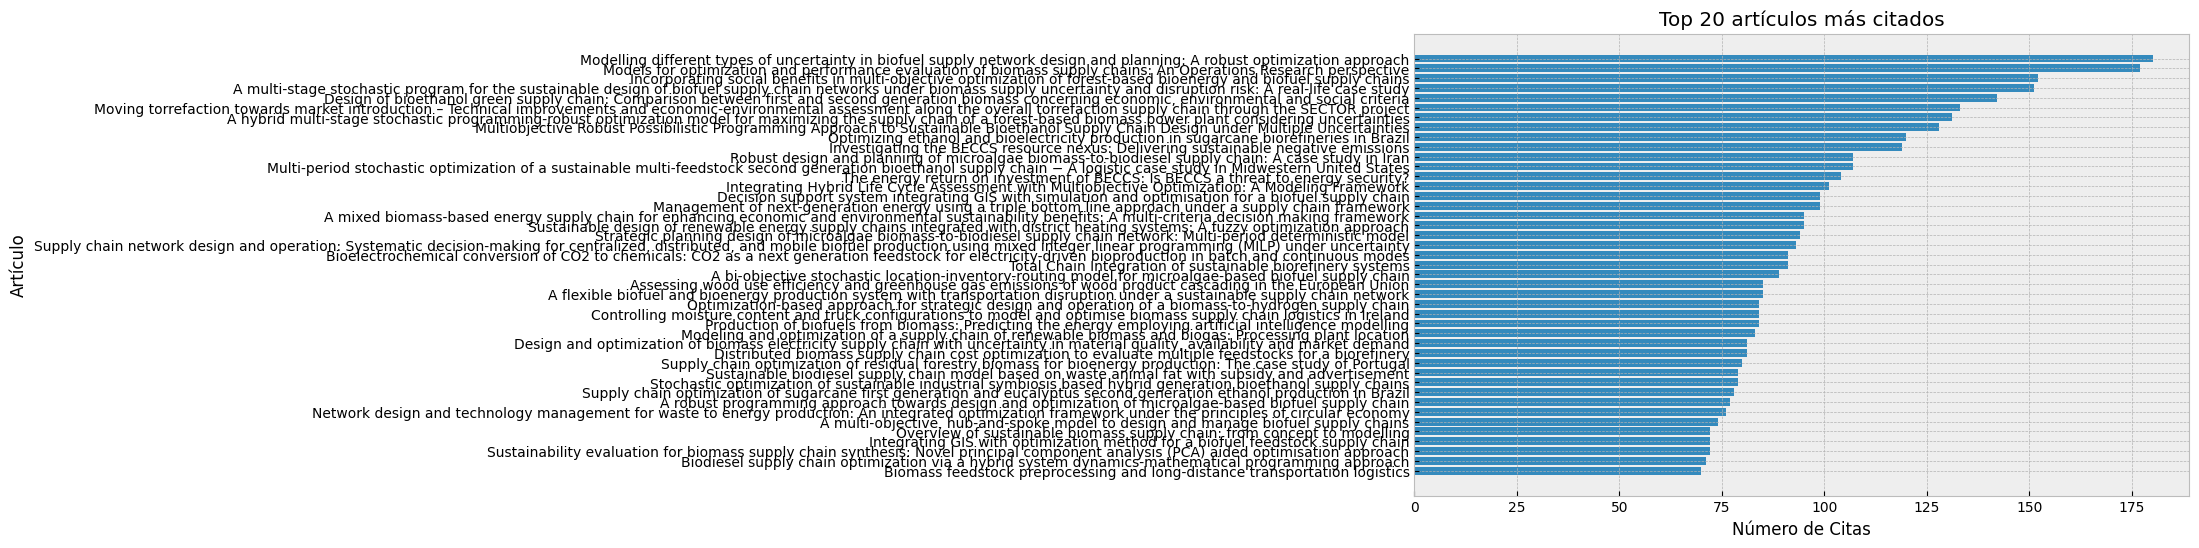

In [ ]:
# Check Reference IDs (If References are Given)

# df = pd.DataFrame({'Reference': bibfile.u_ref, 'Reference ID': bibfile.u_ref_id})
# data_table.DataTable(df, num_rows_per_page = 15)

import bibtexparser
import re
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Cargar archivo BibTeX ===
with open("/content/scopus593.bib", encoding="utf-8") as bibtex_file:
    bib_database = bibtexparser.load(bibtex_file)

# === 2. Extraer datos relevantes ===
titulos = []
citas = []

for entry in bib_database.entries:
    titulos.append(entry.get("title", "Sin título"))
    note_field = entry.get("note", "")
    match = re.search(r"Cited by:\s*(\d+)", note_field)
    citas.append(int(match.group(1)) if match else 0)

# === 3. Crear DataFrame ===
df_citas = pd.DataFrame({
    "Título": titulos,
    "Citas": citas
})

# === 4. Ordenar por número de citas ===
df_citas = df_citas.sort_values(by="Citas", ascending=False)

# === 5. Visualizar top 100 artículos ===
plt.figure(figsize=(10, 6))
plt.barh(df_citas["Título"].head(43), df_citas["Citas"].head(43))
plt.xlabel("Número de Citas")
plt.ylabel("Artículo")
plt.title("Top 20 artículos más citados")
plt.gca().invert_yaxis()
plt.show()


# Exploratory Data Analysis
---
In this section, we will perform EDA

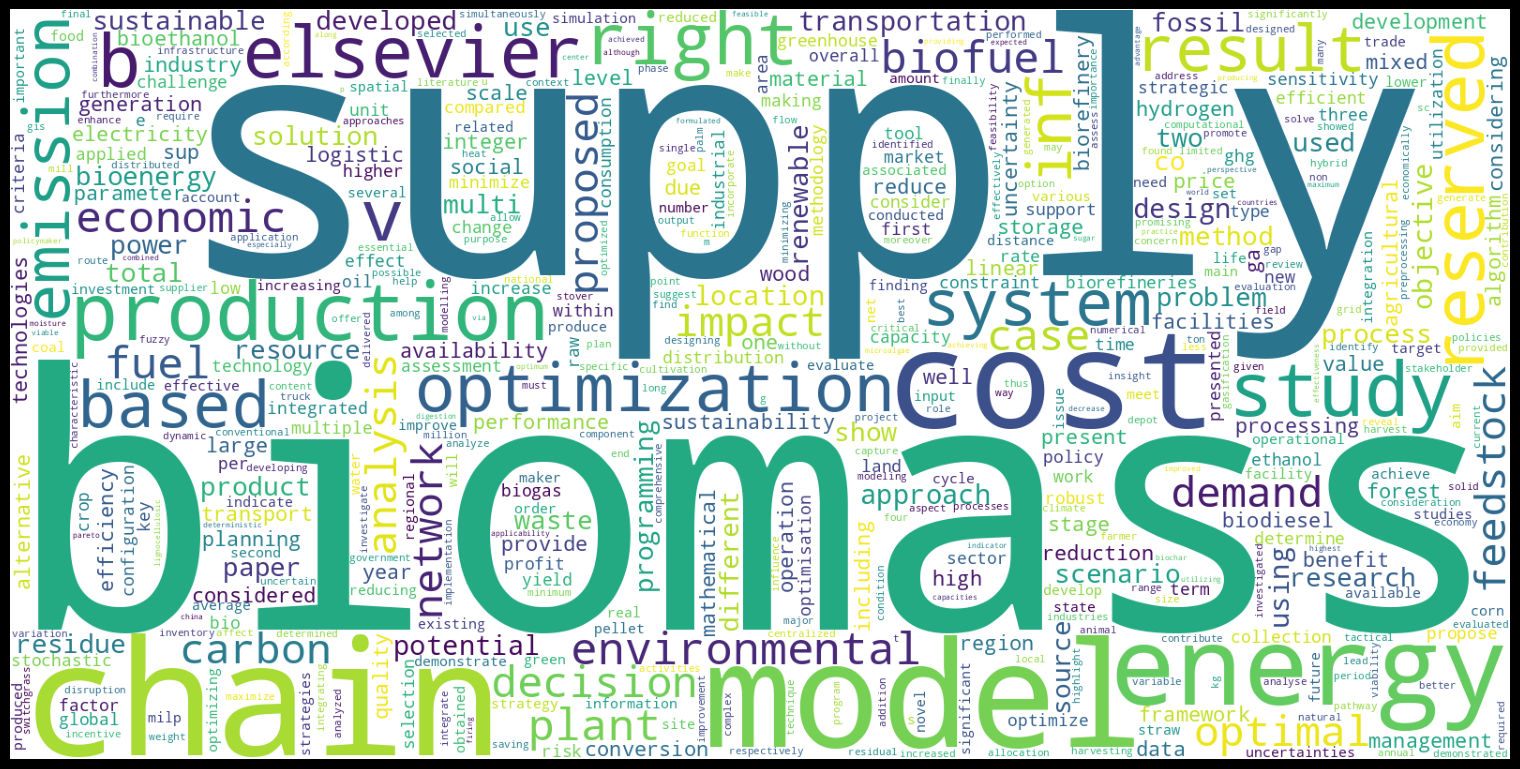

In [ ]:
# WordCloud from the Abstracts, Title, Authors Keywords or Keywords Plus
# Arguments: entry             = 'abs', 'title', 'kwa', or 'kwp'
#            rmv_custom_words  = A list of custom stopwords to clean the corpus;
bibfile.word_cloud_plot(entry = 'abs', size_x = 15, size_y = 10, wordsn = 500, rmv_custom_words = [])

In [ ]:
# Check Table
num_columns = 5
data_wd     = bibfile.ask_gpt_wd
items       = list(data_wd.items())

field_names = []
for i in range(num_columns):
    field_names.append(f"Word {i + 1}")
    field_names.append(f"Importance {i + 1}")

table = PrettyTable()
table.field_names = field_names

for i in range(0, len(items), num_columns):
    row = []
    for j in range(num_columns):
        if i + j < len(items):
            word, importance = items[i + j]
            row.extend([word, round(importance, 4)])
        else:
            row.extend(["", ""])
    table.add_row(row)

# Print the table
print(table)

+---------------+--------------+-----------------+--------------+----------------+--------------+----------------+--------------+----------------+--------------+
|     Word 1    | Importance 1 |      Word 2     | Importance 2 |     Word 3     | Importance 3 |     Word 4     | Importance 4 |     Word 5     | Importance 5 |
+---------------+--------------+-----------------+--------------+----------------+--------------+----------------+--------------+----------------+--------------+
|    biomass    |     1.0      |      supply     |    0.9941    |     chain      |    0.8523    |     model      |    0.7165    |      cost      |    0.6299    |
|     energy    |    0.5077    |    production   |    0.4442    |     study      |    0.3921    |       b        |    0.3618    |       v        |    0.3582    |
|     right     |    0.3511    |     elsevier    |    0.3499    |    reserved    |    0.3499    |  optimization  |    0.3049    |     result     |    0.2794    |
|     system    |    0.277  

In [ ]:
# N-Grams
# Arguments: view       = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            entry      = 'abs', 'title', 'kwa', or 'kwp'
#            n_grams    = An integer with size n (representing the most common groups of words with size n)
#            stop_words = A list of stopwords to clean the corpus. ['ar', 'bn', 'bg', 'cs', 'en', 'fi', 'fr', 'de', 'el', 'hi', 'he', 'hu', 'it', 'ja', 'ko',  'mr', 'fa', 'pl', 'pt-br', 'ro', 'ru', 'es', 'sv', 'sk', 'zh', 'th', 'uk'];
#                         'ar' = Arabic; 'bn' = Bengali; 'bg' = Bulgarian; 'cs' = Czech; 'en' = English; 'fi' = Finnish; 'fr' = French; 'de' = German; 'el' = Greek; 'he' = Hebrew;'hi' = Hindi; 'hu' = Hungarian; 'it' = Italian;
#                         'ja' = Japanese; 'ko' = Korean; 'mr' =  Marathi; 'fa' =  Persian; 'pl' =  Polish; 'pt-br' = Portuguese-Brazilian; 'ro' = Romanian; 'ru' = Russian; 'es' =  Spanish; 'sk' = Slovak; 'sv' = Swedish;
#                         'zh' = Chinese; 'th' = Thai; 'uk' = Ukrainian
#            rmv_custom_words  = A list of custom stopwords to clean the corpus
#             wordsn           = Number of N-Grams
bibfile.get_top_ngrams(view = 'notebook', entry = 'kwp', ngrams = 3, stop_words = [], rmv_custom_words = [], wordsn = 15)





In [ ]:
# Check Table
data_ng = bibfile.ask_gpt_ng
data_table.DataTable(data_ng, num_rows_per_page = 15)

,Word,Freq
0,supply chain management,167
1,biomass supply chain,94
2,mixed integer linear,92
3,integer linear programming,91
4,supply chain network,58
5,supply chain optimization,57
6,cost benefit analysis,56
7,supply chains biomass,53
8,economic and social,51
9,and social effects,49


In [26]:
# Documents Projection based on Words. (An interactive plot). It returns the Projection (each document coordinate) and the Labels (each document cluster)
# Arguments: view              = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            corpus_type       = 'abs', 'title', 'kwa', or 'kwp';
#            stop_words        = A list of stopwords to clean the corpus. ['ar', 'bn', 'bg', 'cs', 'en', 'fi', 'fr', 'de', 'el', 'hi', 'he', 'hu', 'it', 'ja', 'ko',  'mr', 'fa', 'pl', 'pt-br', 'ro', 'ru', 'es', 'sv', 'sk', 'zh', 'th', 'uk'];
#                                'ar' = Arabic; 'bn' = Bengali; 'bg' = Bulgarian; 'cs' = Czech; 'en' = English; 'fi' = Finnish; 'fr' = French; 'de' = German; 'el' = Greek; 'he' = Hebrew;'hi' = Hindi; 'hu' = Hungarian; 'it' = Italian;
#                                'ja' = Japanese; 'ko' = Korean; 'mr' =  Marathi; 'fa' =  Persian; 'pl' =  Polish; 'pt-br' = Potuguese-Brazilian; 'ro' = Romanian; 'ru' = Russian; 'es' =  Spanish; 'sk' = Slovak; 'sv' = Swedish;
#                                'zh' = Chinese; 'th' = Thai; 'uk' = Ukrainian
#            rmv_custom_words  = A list of custom stopwords to clean the corpus;
#            custom_label      = A list of custom labels for each document. The user can define each document cluster;
#            custom_projection = A list of custom coordinates for each document. The user can define each document coordinate;
#            n_components      = Number of Dimensions;
#            n_clusters        = Only relevant if  cluster_method = 'kmeans'.Number of Clusters.;
#            node_labels       = If True, labels appear in nodes;
#            node_size         = Node size;
#            node_font_size    = Node font size;
#            tf_idf            = True or False (True -> The Cluster Algorithm will use the DTM to calculate each document Label. False -> The Cluster Algorithm will use the Coordinates to calculate each document Label);
#            embeddings        = True or False (True -> The Cluster Algorithm will use the Word Embeddings to calculate each document Label. False -> The Cluster Algorithm will use the Coordinates to calculate each document Label);
#            model             = Only relevant if 'embeddings = True'. Specifies the used AI model. The default value is 'allenai/scibert_scivocab_uncased';
#            method            = 'tsvd' or 'umap' ('tsvd' -> Truncated SVD projection method is used. 'umap' -> UMAP projection method is used);
#            showlegend        = If True, shows legend;
#            cluster_method    = 'kmeans' or 'hdbscan';
#            min_size          = Only relevant if  cluster_method = 'hdbscan'. Minimum number of elements in a Cluster;
#            max_size          = Only relevant if  cluster_method = 'hdbscan'. Maximum number of elements in a Cluster
projection, labels = bibfile.docs_projection(view              = 'notebook',
                                             corpus_type       = 'abs',
                                             stop_words        = ['en'],
                                             rmv_custom_words  = [],
                                             custom_label      = [],
                                             custom_projection = [],
                                             n_components      = 2,
                                             n_clusters        = 3,
                                             node_labels       = True,
                                             node_size         = 12,
                                             node_font_size    = 4,
                                             tf_idf            = False,
                                             embeddings        = False,
                                             model             = 'allenai/scibert_scivocab_uncased',
                                             method            = 'umap',
                                             showlegend        = True,
                                             cluster_method    = 'kmeans',
                                             min_size          = 4,
                                             max_size          = 50
                                             )

In [27]:
# Check Table
data_pr = pd.DataFrame(np.hstack([projection, labels.reshape(-1,1)]))
data_table.DataTable(data_pr, num_rows_per_page = 15)

,0,1,2
0,6.446229,6.072491,2.0
1,4.537067,6.609255,0.0
2,9.682725,5.619086,1.0
3,5.343584,6.857233,0.0
4,6.156412,5.789398,2.0
...,...,...,...
588,7.349512,6.538877,2.0
589,7.181253,5.006717,2.0
590,7.759089,5.043467,2.0
591,7.461864,7.328991,1.0


In [121]:
# Check Articles per Cluster
cluster      = 0
idx_articles = [i for i in range(0, labels.shape[0]) if labels[i] == cluster]
print(*idx_articles, sep = ', ')
# Contar cuántos documentos hay en ese cluster
print("Número de documentos en el clúster", cluster, ":", len(idx_articles))

1, 3, 6, 12, 13, 15, 17, 21, 22, 28, 29, 31, 36, 37, 40, 45, 49, 53, 66, 67, 68, 71, 83, 85, 88, 89, 91, 95, 98, 99, 100, 101, 103, 110, 111, 112, 114, 120, 121, 128, 132, 134, 135, 142, 144, 145, 146, 147, 148, 149, 151, 154, 156, 159, 162, 163, 164, 168, 170, 171, 174, 178, 179, 180, 181, 183, 184, 185, 186, 187, 188, 189, 191, 193, 196, 201, 202, 203, 204, 212, 213, 218, 219, 220, 224, 227, 229, 232, 233, 234, 235, 242, 245, 248, 252, 254, 255, 256, 258, 260, 261, 262, 266, 268, 271, 278, 279, 282, 287, 290, 294, 295, 297, 299, 302, 304, 305, 306, 307, 308, 311, 312, 315, 316, 317, 320, 321, 323, 327, 328, 329, 336, 340, 346, 352, 359, 360, 362, 363, 367, 369, 371, 375, 376, 378, 382, 385, 386, 388, 391, 393, 395, 397, 400, 403, 405, 406, 407, 411, 414, 417, 419, 423, 425, 427, 429, 430, 431, 432, 434, 435, 436, 440, 441, 443, 446, 447, 449, 451, 453, 455, 456, 464, 467, 469, 471, 473, 475, 478, 480, 481, 484, 485, 486, 487, 491, 492, 493, 495, 497, 499, 500, 502, 503, 504, 506, 507

In [32]:
# Arguments: view              = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            key               = 'abs', 'title', 'jou, 'kwa', or 'kwp';
#            stop_words        = A list of stopwords to clean the corpus. ['ar', 'bn', 'bg', 'cs', 'en', 'fi', 'fr', 'de', 'el', 'hi', 'he', 'hu', 'it', 'ja', 'ko',  'mr', 'fa', 'pl', 'pt-br', 'ro', 'ru', 'es', 'sv', 'sk', 'zh', 'th', 'uk'];
#                                'ar' = Arabic; 'bn' = Bengali; 'bg' = Bulgarian; 'cs' = Czech; 'en' = English; 'fi' = Finnish; 'fr' = French; 'de' = German; 'el' = Greek; 'he' = Hebrew;'hi' = Hindi; 'hu' = Hungarian; 'it' = Italian;
#                                'ja' = Japanese; 'ko' = Korean; 'mr' =  Marathi; 'fa' =  Persian; 'pl' =  Polish; 'pt-br' = Potuguese-Brazilian; 'ro' = Romanian; 'ru' = Russian; 'es' =  Spanish; 'sk' = Slovak; 'sv' = Swedish;
#                                'zh' = Chinese; 'th' = Thai; 'uk' = Ukrainian
#            rmv_custom_words  = A list of custom stopwords to clean the corpus;
#            topn              = Total number entities;
#            txt_font_size     = Font size of the text inside the bins;
#            start             = Start Year; -1 = all years
#            end               = End Year;   -1 = all years
bibfile.plot_evolution_year(view             = 'notebook',
                            stop_words       = [],
                            rmv_custom_words = [],
                            key              = 'kwa',
                            topn             = 10,
                            txt_font_size    = 12,
                            start            = 2005,
                            end              = 2025)

In [33]:
# View Table
data_ep = bibfile.ask_gpt_ep
print(textwrap.fill(data_ep, 150))

 2015: supply chains (23), biomass (21), optimization (18), chains (9), biofuels (9), integer programming (9), costs (7), greenhouse gases (7),
forestry (6), biofuel (6) 2016: supply chains (41), biomass (35), optimization (34), supply chain management (18), integer programming (18), biofuel
(14), sustainable development (14), decision making (13), costs (13), bioenergy (12) 2017: biomass (30), supply chains (27), optimization (24), supply
chain management (21), integer programming (11), biofuel (11), costs (11), biofuels (10), cost benefit analysis (9), ethanol (8) 2018: biomass (34),
supply chains (34), optimization (22), integer programming (17), supply chain management (16), biofuels (11), sustainable development (11), feedstocks
(11), biomass supply chain (10), decision making (10) 2019: supply chains (38), biomass (30), optimization (21), supply chain management (15), integer
programming (13), supply chain (10), feedstocks (9), costs (9), refining (9), biofuels (9) 2020: biomass 

In [122]:
# Arguments: view              = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn              = Most frequent n words
#            custom            = Plot specific words
bibfile.plot_evolution_year_complement(data_ep, view = 'notebook', topn = 15, custom = [])

In [35]:
# Sankey Diagram (An interactive plot)
# Arguments:
#   view         : Determines the rendering mode.'notebook' -> Plots in your preferred Notebook app. 'browser'  -> Plots in your preferred browser window.
#   entry        : A list defining the sequence of data columns to be visualized. Allowed keys: 'aut', 'cout', 'inst', 'jou', 'kwa', 'kwp', 'lan'
#   rmv_unknowns : Boolean flag controlling how unknown entries are handled. True  -> Remove any relationships that include 'unknown'.
#   topn         : Specifies the maximum number of top entities/connections to display at each level. Set to "None" for no filtering or provide a list with limits corresponding to each connection between the nodes defined in 'entry'.
bibfile.sankey_diagram(view = 'notebook', entry = ['aut', 'cout', 'lan'], topn = [10, 15], rmv_unknowns = True)

# PS: The white bars can be dragged

In [36]:
# View Table
data_sk = bibfile.ask_gpt_sk
data_table.DataTable(data_sk, num_rows_per_page = 15)

,Node From,Node To,Connection Weigth
0,"lam, hon loong",Malaysia,13
1,"ponce-ortega, josé maría",Mexico,8
2,"ponce-ortega, josé maría",Israel,2
3,"ponce-ortega, josé maría",Saudi Arabia,2
4,"ponce-ortega, josé maría",United States of America,1
5,"ponce-ortega, josé maría",United Kingdom,1
6,"sowlati, taraneh",Canada,13
7,"how, b. s.",Malaysia,9
8,"how, b. s.",Brunei Darussalam,1
9,"how, b. s.",Netherlands,1


In [37]:
# Plot Count Y per X (An interactive bar chart)
# Arguments:
#   view          : Determines where the plot will be rendered. 'browser'  -> Plots in your preferred browser window. 'notebook' -> (if supported) Plots within your notebook environment.
#   rmv_unknowns  : Boolean flag to handle unknown entries. True  -> Removes any relationships containing unknown values.
#   x             : The key (column) to use for the X-axis. Must be one of: 'aut', 'cout', 'inst', 'jou', 'kwa', 'kwp', 'lan'. Default is 'cout'.
#   y             : The key (column) to use for the Y-axis. Must be one of: 'aut', 'cout', 'inst', 'jou', 'kwa', 'kwp', 'lan'. Default is 'aut'.
#   topn_x        : Maximum number of top X categories (based on total counts) to display. Default is 5.
#   topn_y        : Maximum number of top Y entries (per X category) to display. Default is 5.
#   text_font_size: Font size for the text labels displayed inside the bars. Default is 12.
#   x_angle       : Angle (in degrees) for the X-axis tick labels. Default is -90 (rotating labels vertically).
bibfile.plot_count_y_per_x(view = 'notebook', rmv_unknowns = True, x = 'cout', y = 'aut', topn_x = 5, topn_y = 5, text_font_size = 12, x_angle = -90)

In [38]:
# View Table
data_table.DataTable(bibfile.top_y_x, num_rows_per_page = 15)

,Count,X (Countries),Y (Authors)
275,13,Canada,"sowlati, taraneh"
612,4,Canada,"ahmadvand, sahar"
104,3,Canada,"rönnqvist, mikael"
783,3,Canada,"lebel, luc g."
1044,3,Canada,"mafakheri, fereshteh"
213,3,China,"ji, ling"
1643,3,China,"zhang, fengli"
79,2,China,"li, qiaofeng"
81,2,China,"wang, lu"
130,2,China,"govindan, kannan"


In [39]:
# Tree Map
# Arguments: view          = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            entry         = 'kwp', 'kwa', 'aut', 'jou', 'ctr', or 'inst';
#            topn          = Total number entities
#            txt_font_size = Font size of the text inside the bins;
bibfile.tree_map(view = 'notebook', entry = 'jou', topn = 20)

In [40]:
# Authors Productivity Plot (An interactive plot). It informs for each year the documents (IDs) published for each author
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn = Total number entities
bibfile.authors_productivity(view = 'notebook', topn = 20)

In [41]:
# View Table
data_ap = bibfile.ask_gpt_ap
data_table.DataTable(data_ap, num_rows_per_page = 15)

,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
"ponce-ortega, josé maría",3.0,2.0,4.0,0.0,1.0,0.0,1.0,2.0,1.0,0.0,0.0
"lam, hon loong",1.0,3.0,3.0,3.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0
"sowlati, taraneh",0.0,3.0,0.0,1.0,1.0,3.0,1.0,1.0,2.0,0.0,1.0
"how, b. s.",0.0,2.0,3.0,2.0,1.0,0.0,1.0,1.0,2.0,1.0,0.0
"castillo-villar, krystel k.",0.0,1.0,2.0,1.0,0.0,1.0,2.0,3.0,1.0,0.0,0.0
"santibañez-aguilar, josé ezequiel",2.0,2.0,2.0,0.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0
"sahebi, hadi",0.0,1.0,0.0,1.0,1.0,3.0,1.0,0.0,2.0,1.0,0.0
"sarkar, biswajit",0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,3.0,1.0
"nunes, leonel j.r.",0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0,3.0,0.0
"szmerekovsky, joseph g.",0.0,0.0,0.0,1.0,1.0,3.0,0.0,1.0,1.0,0.0,0.0


In [42]:
# Countries Productivity Plot (An interactive plot). It informs the production for each Country (count is made considering each doc author)
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
bibfile.countries_productivity(view = 'notebook')

In [43]:
# View Table
data_cp = bibfile.ask_gpt_cp
data_table.DataTable(data_cp, num_rows_per_page = 15)

,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,All Years
united states of america,41,34,50,42,41,40,44,30,20,34,48,0,424
china,0,7,8,3,13,7,2,28,31,64,43,0,206
malaysia,4,8,14,10,20,10,20,8,12,11,8,0,125
iran,0,14,0,16,1,11,14,9,14,21,19,4,123
canada,7,12,15,6,12,8,11,5,10,12,10,0,108
...,...,...,...,...,...,...,...,...,...,...,...,...,...
mali,0,0,0,0,0,1,0,0,0,0,0,0,1
tunisia,0,0,0,0,0,0,0,0,0,1,0,0,1
algeria,0,0,0,0,0,0,0,1,0,0,0,0,1
luxembourg,0,0,0,0,0,0,0,0,0,0,1,0,1


In [44]:
# Institutions Productivity Plot (An interactive plot). It informs for each year the documents (IDs) published for each institution
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn = Total number entities
bibfile.institution_productivity(view = 'notebook', topn = 20)

In [45]:
# View Table
data_ip = bibfile.ask_gpt_ip
data_table.DataTable(data_ip, num_rows_per_page = 15)

,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
mauricio a. university of the sunshine coast,2.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
hon loong the university of nottingham malaysia campus,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0
sylvain international institute for applied systems analysis,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
sahar the university of british columbia,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,0.0,0.0
school of science and engineering,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0
pasquale research centre for agriculture and environment (crea-aa),0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
ding henan research center of protected horticulture engineering technology,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
lidija univerza v mariboru,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
min china institute for innovation and development strategy,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
the university of nottingham malaysia campus,0.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [46]:
# Sources Productivity Plot (An interactive plot). It informs for each year the documents (IDs) published for each source (journal)
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn = Total number entities
bibfile.source_productivity(view = 'notebook', topn = 20)

In [47]:
# View Table
data_sp = bibfile.ask_gpt_sp
data_table.DataTable(data_sp, num_rows_per_page = 15)

,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
applied energy,5.0,4.0,6.0,6.0,5.0,8.0,4.0,4.0,1.0,4.0,3.0,0.0
journal of cleaner production,4.0,6.0,2.0,7.0,4.0,3.0,6.0,4.0,3.0,6.0,3.0,0.0
computers and chemical engineering,1.0,2.0,1.0,2.0,5.0,1.0,8.0,6.0,2.0,3.0,5.0,2.0
energy,1.0,4.0,4.0,3.0,5.0,5.0,4.0,1.0,0.0,1.0,4.0,0.0
biomass and bioenergy,2.0,4.0,5.0,2.0,0.0,2.0,2.0,0.0,1.0,2.0,2.0,0.0
renewable energy,1.0,8.0,3.0,1.0,2.0,0.0,1.0,2.0,0.0,1.0,0.0,0.0
energies,0.0,1.0,1.0,0.0,2.0,3.0,3.0,1.0,3.0,2.0,2.0,0.0
sustainability (switzerland),0.0,0.0,1.0,2.0,1.0,3.0,2.0,1.0,4.0,2.0,2.0,0.0
chemical engineering transactions,4.0,0.0,2.0,0.0,0.0,2.0,5.0,2.0,1.0,1.0,0.0,0.0
computers and industrial engineering,1.0,1.0,1.0,0.0,2.0,0.0,0.0,2.0,0.0,3.0,2.0,0.0


In [48]:
# Bar Plots
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#                    statistic = 'dpy', 'cpy', 'ppy', 'ltk', 'spd', 'spc', 'apd', 'apc', 'aph', 'bdf_1', 'bdf_2', 'bdf_3', 'ipd', 'ipc', 'cpd', 'cpc', 'lpd', 'kpd', 'kad'
#                        'dpy' = Documents per Year
#                         cpy' = Citations per Year
#                        'ppy' = Past Citations per Year
#                        'ltk' = Lotka's Law
#                        'spd' = Sources per Documents
#                        'spc' = Sources per Citations
#                        'apd' = Authors per Documents
#                        'apc' = Authors per Citations
#                        'aph' = Authors per H-Index
#                        'bdf_1', 'bdf_2', 'bdf_3' = Bradford's Law - Core Sources 1, 2 or 3
#                        'ipd' = Institutions per Documents
#                        'ipc' = Institutions per Citations
#                        'cpd' = Countries per Documents
#                        'cpc' = Countries per Citations
#                        'lpd' = Language per Documents
#                        'kpd' = Keywords Plus per Documents
#                        'kad' = Authors' Keywords per Documents
#                         topn = Total number entities
bibfile.plot_bars(view = 'notebook', statistic = 'apd', topn = 20)

In [49]:
# View Table
data_bp = bibfile.ask_gpt_bp
data_table.DataTable(data_bp, num_rows_per_page = 15)

,Documents,Authors
0,"ponce-ortega, josé maría",14
1,"lam, hon loong",14
2,"sowlati, taraneh",13
3,"how, b. s.",13
4,"castillo-villar, krystel k.",11
5,"santibañez-aguilar, josé ezequiel",10
6,"sahebi, hadi",10
7,"sarkar, biswajit",8
8,"nunes, leonel j.r.",8
9,"szmerekovsky, joseph g.",7


In [50]:
# Plot Top References
# Arguments: view       = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn       = Specifies the number of top references (by citation count) to display in the plot;
#            font_size  = Controls the font size of the legend in the plot;
#            use_ref_id = Chooses between using reference names or reference IDs when processing and plotting data;
#            date_start = If provided, shows citing articles with a publication year greater than or equal to this value are included. If None, then there is no lower limit on the publication year.
#            date_end   = If provided, shows citing articles with a publication year less than or equal to this value are included. If None, then there is no upprer limit on the publication year.
bibfile.plot_top_refs(view = 'notebook', topn = 10, font_size = 10, use_ref_id = False, date_start = None, date_end = None)


In [51]:
# Check Top References
data_table.DataTable(bibfile.top_refs, num_rows_per_page = 15)

# PS: Optionally, use 'bibfile.merge_reference(get = [], replace_for = 'name')' to correct References
# wrong_references = [
#                     'Mousseau, V., Slowinski, R., Inferring an ELECTRE TRI model from assignment examples (1998) Journal of Global Optimization, 12, pp. 157-174',
#                     'Mousseau, V., Słowiński, R., Inferring an ELECTRE TRI model from assignment examples (1998) Journal of Global Optimization, 12 (2), pp. 157-174'
#                    ]
# correct_reference = 'Mousseau, V., Slowinski, R., Inferring an ELECTRE TRI model from assignment examples (1998) Journal of Global Optimization, 12 (2), pp. 157-174'
# bibfile.merge_reference(get = wrong_references, replace_for = correct_reference)

,Reference,Reference ID,Reference Year,Raw Citation Counts


In [53]:
# Citation Trajectory
# Arguments: view     = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#           ref_names = If provided (i.e., nonempty), the function uses these reference names to track and plot citation trajectories;
#           ref_ids   = If ref_names is empty but ref_ids is provided, the function will use these IDs instead.
bibfile.plot_citation_trajectory(view = 'notebook', ref_names = [], ref_ids = [1, 3, 6, 12, 13, 15, 17, 21, 22, 28, 29, 31, 36, 37, 40, 45, 49, 53, 66, 67, 68, 71, 83, 85, 88, 89, 91, 95, 98, 99, 100, 101, 103, 110, 111, 112, 114, 120, 121, 128, 132, 134, 135, 142, 144, 145, 146, 147, 148, 149, 151, 154, 156, 159, 162, 163, 164, 168, 170, 171, 174, 178, 179, 180, 181, 183, 184, 185, 186, 187, 188, 189, 191, 193, 196, 201, 202, 203, 204, 212, 213, 218, 219, 220, 224, 227, 229, 232, 233, 234, 235, 242, 245, 248, 252, 254, 255, 256, 258, 260, 261, 262, 266, 268, 271, 278, 279, 282, 287, 290, 294, 295, 297, 299, 302, 304, 305, 306, 307, 308, 311, 312, 315, 316, 317, 320, 321, 323, 327, 328, 329, 336, 340, 346, 352, 359, 360, 362, 363, 367, 369, 371, 375, 376, 378, 382, 385, 386, 388, 391, 393, 395, 397, 400, 403, 405, 406, 407, 411, 414, 417, 419, 423, 425, 427, 429, 430, 431, 432, 434, 435, 436, 440, 441, 443, 446, 447, 449, 451, 453, 455, 456, 464, 467, 469, 471, 473, 475, 478, 480, 481, 484, 485, 486, 487, 491, 492, 493, 495, 497, 499, 500, 502, 503, 504, 506, 507, 510, 512, 514, 518, 520, 521, 522, 527, 528, 529, 532, 537, 538, 542, 546, 547, 548, 549, 550, 551, 553, 556, 560, 561, 563, 564, 565, 567, 569, 570, 571, 572, 574, 576, 577, 578, 579, 585, 586])


In [54]:
# References Citation Matrix
# Arguments: tgt_ref_id = For a nonempty list, show olny the references in the list. An empty list (the default), shows all references;
#            date_start = If provided, shows citing articles with a publication year greater than or equal to this value are included. If None, then there is no lower limit on the publication year;
#            date_end   = If provided, shows citing articles with a publication year less than or equal to this value are included. If None, then there is no upprer limit on the publication year.
ct_matrix = bibfile.ref_citation_matrix(tgt_ref_id = [], date_start = None, date_end = None)

# Check Citation Matrix. Citing Articles are in the format (Article ID, Year)
ct_matrix

KeyError: 'Reference'

In [55]:
# RPYS (Reference Publication Year Spectroscopy) with Gaussian Filter to Find Peaks
# Arguments: view       = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            peaks_only = If False, the function plots data for all publication years. If True, shows only peaks.
bibfile.plot_rpys(view = 'notebook', peaks_only = False)

# PS: Use the Slider to focus in a range of years

In [56]:
# Check RPYS Data
data_table.DataTable(bibfile.rpys_rs, num_rows_per_page = 15)

,Years,Raw Citation Counts,Smoothed Citation Counts


In [57]:
# Check RPYS Data Peaks
data_table.DataTable(bibfile.rpys_pk, num_rows_per_page = 15)

,Peak Years,Counts


# Network Analysis
---
In this section, we will perform Network Analysis

In [58]:
# References Top Cited Co-References
# Arguments: groups = controls how many references are considered together;
#            topn   = Specifies the number of top references (by citation count) to display in the plot;
co_cited = bibfile.top_cited_co_references(group = 4, topn = 10)
co_cited

,Reference ID Sets,Count


In [59]:
# Plot Co-Citation Network
# Arguments:  view       = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#             tgt_ref_id = The reference ID;
#             topn       = Specifies the number of top references (by citation count) to display in the plot;
#bibfile.plot_co_citation_network(view = 'notebook', target_ref_id = 'r_5607', topn = 10)
bibfile.plot_co_citation_network(view='notebook', target_ref_id =[], topn=20)

TypeError: unhashable type: 'list'

In [60]:
# Check Co-Citation Network
data_table.DataTable(bibfile.top_co_c, num_rows_per_page = 15)

,Reference ID,Reference,Year,Count


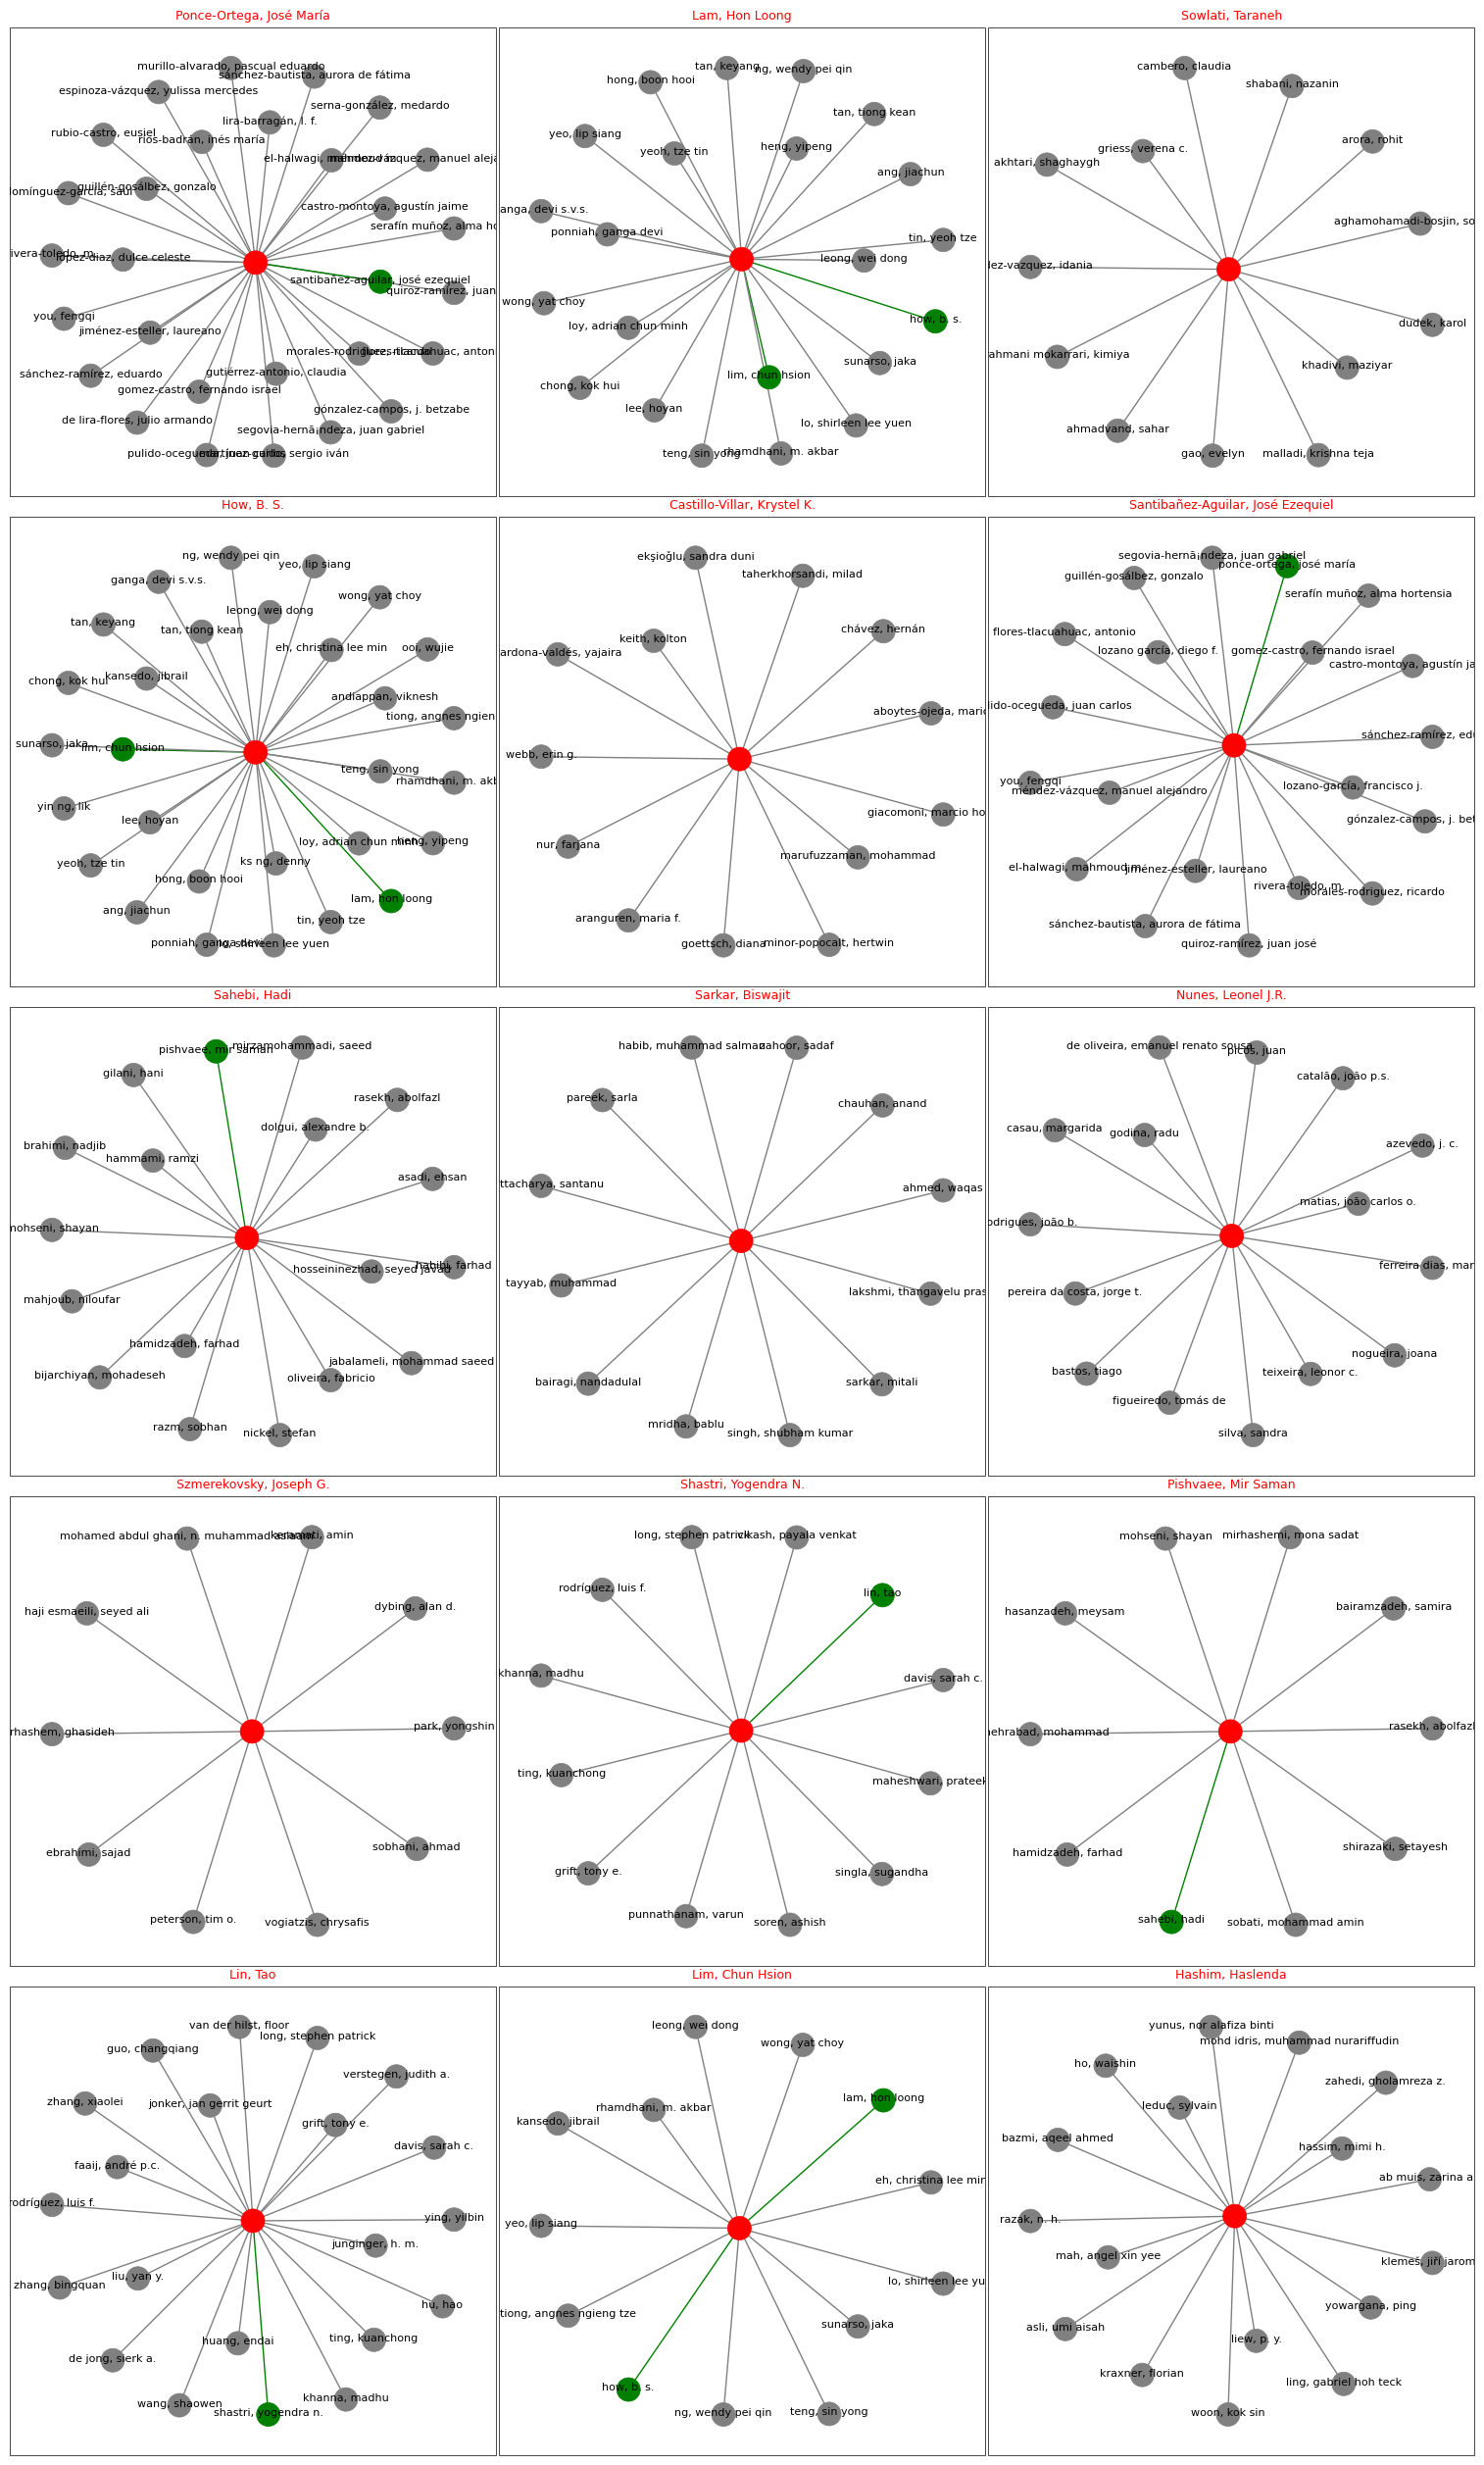

In [61]:
# Arguments:
# entry      = 'aut', 'cout', 'inst', 'kwa', or 'kwp'.
# tgt        = List of specific names.
# topn       = Integer. Specifies the number of top authors to display based on their total contributions.
# rows       = Integer. Defines the number of rows in the subplot grid for the visual layout.
# cols       = Integer. Defines the number of columns in the subplot grid for the visual layout.
# wspace     = Float. Adjusts horizontal spacing between subplots.
# hspace     = Float. Adjusts vertical spacing between subplots.
# tspace     = Float. Sets additional vertical space between nodes and labels for better readability.
# node_size  = Integer. Controls the size of each node in the network graph.
# font_size  = Integer. Defines the font size for node labels.
# pad        = Float. Adjusts padding around the layout for a balanced appearance.
# nd_a       = Color string (e.g., '#FF0000'). Specifies the color for the primary node (main author).
# nd_b       = Color string (e.g., '#008000'). Specifies the color for secondary nodes (authors with significant links).
# nd_c       = Color string (e.g., '#808080'). Specifies the color for other nodes (authors with minor links).
# verbose    = Boolean. If True, prints details of each main node and its connections in the console; if False, suppresses this output.
bibfile.network_collab( entry     = 'aut',
                        tgt       = [],
                        topn      = 15,
                        rows      = 5,
                        cols      = 3,
                        wspace    = 0.2,
                        hspace    = 0.2,
                        tspace    = 0.01,
                        node_size = 300,
                        font_size = 8,
                        pad       = 0.2,
                        nd_a      = '#FF0000',
                        nd_b      = '#008000',
                        nd_c      = '#808080',
                        verbose   = False)

In [62]:
# Check Collab
print(bibfile.ask_gpt_ct)

[[['ponce-ortega, josé maría'], ['castro-montoya, agustín jaime', 'de lira-flores, julio armando', 'domínguez-garcía, saúl', 'el-halwagi, mahmoud m.', 'espinoza-vázquez, yulissa mercedes', 'flores-tlacuahuac, antonio', 'gomez-castro, fernando israel', 'guillén-gosálbez, gonzalo', 'gutiérrez-antonio, claudia', 'gónzalez-campos, j. betzabe', 'jiménez-esteller, laureano', 'lira-barragán, l. f.', 'lópez-diaz, dulce celeste', 'martínez-guido, sergio iván', 'morales-rodriguez, ricardo', 'murillo-alvarado, pascual eduardo', 'méndez-vázquez, manuel alejandro', 'pulido-ocegueda, juan carlos', 'quiroz-ramírez, juan josé', 'rivera-toledo, m.', 'rubio-castro, eusiel', 'ríos-badrán, inés maría', 'santibañez-aguilar, josé ezequiel', 'segovia-hernã¡ndeza, juan gabriel', 'serafín muñoz, alma hortensia', 'serna-gonzález, medardo', 'sánchez-bautista, aurora de fátima', 'sánchez-ramírez, eduardo', 'you, fengqi']], [['lam, hon loong'], ['ang, jiachun', 'chong, kok hui', 'ganga, devi s.v.s.', 'heng, yipeng

In [63]:
# Network - Citation Analisys Between Documents (Blue Nodes) and Citations (Red Nodes).  (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            min_count   = Relationship between nodes that have been cited at least x times;
#            node_labels = True or False (True -> The label IDs will be displayed, False -> Only the nodes will be displayed );
#            node_size   = Integer. Value for node size;
#            font_size   = Integer. Defines the font size for node labels;
#            local_nodes = True or False (True -> Only the blue will be displayed, False -> Red and Blue nodes will be displayed)
bibfile.network_adj_dir(view = 'notebook', min_count = 2, node_labels = True, node_size = 20, font_size = 8, local_nodes = False)

In [64]:
# View Table
data_nad = bibfile.ask_gpt_nad
data_table.DataTable(data_nad, num_rows_per_page = 15)

,Paper,Cited Reference


In [65]:
# Network - Highlight Citation Analysis Between Documents (Blue Nodes) and Citations (Red Nodes).  (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            article_ids = A list of Blue Nodes. It indicates the documents cited by them;
#            ref_ids     = A list of Red Nodes. It indicates the documents that cites them;
#            font_size   = Integer. Defines the font size for node labels;
#            node_size   = Integer. Value for node size
bibfile.find_nodes_dir(view = 'notebook', article_ids = [], ref_ids = [], node_size = 20, font_size = 10)

In [66]:
# Network - Highlight Citation Analysis Between Documents (Blue Nodes) and Citations (Red Nodes).  (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            article_ids = A list of Blue Nodes. It indicates the documents cited by them;
#            ref_ids     = A list of Red Nodes. It indicates the documents that cites them;
#            font_size   = Integer. Defines the font size for node labels;
#            node_size   = Integer. Value for node size
bibfile.find_nodes_dir(view = 'notebook', article_ids = [], ref_ids = [], node_size = 20, font_size = 10)

In [67]:
# Network - Local Documents (Only Blue Nodes) Citation History. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            min_links   = Relationship between nodes that have connected at least x times;
#            node_size   = Integer. Value for node size;
#            font_size   = Integer. Defines the font size for node labels;
#            node_labels = True or False (True -> The label IDs will be displayed, False -> Only the nodes will be displayed );
#            chain       = A list of documents. It shows the documents and their citations;
#            path       =  Only relevant if 'chain' is not empty. True -> Show only the documents in 'chain'. False -> Show documents and connections.
citations = bibfile.network_hist(view = 'notebook', min_links = 0, chain = [], path = False, node_size = 20, font_size = 10, node_labels = True)

In [68]:
# View Table
data_hist = bibfile.ask_gpt_hist
data_table.DataTable(data_hist, num_rows_per_page = 15)

,Paper ID (Year),Reference ID (Year)


In [69]:
citations = bibfile.network_hist(view = 'notebook', min_links = 0, chain = [1, 3, 6, 12, 13, 15, 17, 21, 22, 28, 29, 31, 36, 37, 40, 45, 49, 53, 66, 67, 68, 71, 83, 85, 88, 89, 91, 95, 98, 99, 100, 101, 103, 110, 111, 112, 114, 120, 121, 128, 132, 134, 135, 142, 144, 145, 146, 147, 148, 149, 151, 154, 156, 159, 162, 163, 164, 168, 170, 171, 174, 178, 179, 180, 181, 183, 184, 185, 186, 187, 188, 189, 191, 193, 196, 201, 202, 203, 204, 212, 213, 218, 219, 220, 224, 227, 229, 232, 233, 234, 235, 242, 245, 248, 252, 254, 255, 256, 258, 260, 261, 262, 266, 268, 271, 278, 279, 282, 287, 290, 294, 295, 297, 299, 302, 304, 305, 306, 307, 308, 311, 312, 315, 316, 317, 320, 321, 323, 327, 328, 329, 336, 340, 346, 352, 359, 360, 362, 363, 367, 369, 371, 375, 376, 378, 382, 385, 386, 388, 391, 393, 395, 397, 400, 403, 405, 406, 407, 411, 414, 417, 419, 423, 425, 427, 429, 430, 431, 432, 434, 435, 436, 440, 441, 443, 446, 447, 449, 451, 453, 455, 456, 464, 467, 469, 471, 473, 475, 478, 480, 481, 484, 485, 486, 487, 491, 492, 493, 495, 497, 499, 500, 502, 503, 504, 506, 507, 510, 512, 514, 518, 520, 521, 522, 527, 528, 529, 532, 537, 538, 542, 546, 547, 548, 549, 550, 551, 553, 556, 560, 561, 563, 564, 565, 567, 569, 570, 571, 572, 574, 576, 577, 578, 579, 585, 586
], path = False, node_size = 20, font_size = 10, node_labels = True)

In [70]:
citations = bibfile.network_hist(view = 'notebook', min_links = 0, chain = [1, 3, 6, 12, 13, 15, 17, 21, 22, 28, 29, 31, 36, 37, 40, 45, 49, 53, 66, 67, 68, 71, 83, 85, 88, 89, 91, 95, 98, 99, 100, 101, 103, 110, 111, 112, 114, 120, 121, 128, 132, 134, 135, 142, 144, 145, 146, 147, 148, 149, 151, 154, 156, 159, 162, 163, 164, 168, 170, 171, 174, 178, 179, 180, 181, 183, 184, 185, 186, 187, 188, 189, 191, 193, 196, 201, 202, 203, 204, 212, 213, 218, 219, 220, 224, 227, 229, 232, 233, 234, 235, 242, 245, 248, 252, 254, 255, 256, 258, 260, 261, 262, 266, 268, 271, 278, 279, 282, 287, 290, 294, 295, 297, 299, 302, 304, 305, 306, 307, 308, 311, 312, 315, 316, 317, 320, 321, 323, 327, 328, 329, 336, 340, 346, 352, 359, 360, 362, 363, 367, 369, 371, 375, 376, 378, 382, 385, 386, 388, 391, 393, 395, 397, 400, 403, 405, 406, 407, 411, 414, 417, 419, 423, 425, 427, 429, 430, 431, 432, 434, 435, 436, 440, 441, 443, 446, 447, 449, 451, 453, 455, 456, 464, 467, 469, 471, 473, 475, 478, 480, 481, 484, 485, 486, 487, 491, 492, 493, 495, 497, 499, 500, 502, 503, 504, 506, 507, 510, 512, 514, 518, 520, 521, 522, 527, 528, 529, 532, 537, 538, 542, 546, 547, 548, 549, 550, 551, 553, 556, 560, 561, 563, 564, 565, 567, 569, 570, 571, 572, 574, 576, 577, 578, 579, 585, 586
], path = True, node_size = 20, font_size = 10, node_labels = False)

In [71]:
# Network - Analyze Hist. Citations
# Arguments: min_path_size = Minimum number of elements of a path.
hist_paths = bibfile.analyze_hist_citations(citations, min_path_size = 2)

Most Referenced Paper ID: None -> Cited 0 Times
Paper ID that Cites the Most: None -> Cites 0 Papers


In [116]:
# Network - Collaboration Analysis Between Authors, Countries, Intitutions Or Adjacency Analysis Between Authors' Keywords or Keywords Plus. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            adj_type    = 'aut', 'cout', 'inst', 'kwa', or 'kwp'
#            min_count   = Relationship between nodes that have connected at least x times;
#            node_labels = True or False (True -> The label IDs will be displayed, False -> Only the nodes will be displayed );
#            node_size   = -1. (If node_size = -1 then the default value will be used. If node_size > 0 then this new value will be used);
#            label_type  = 'id', 'name' (Only meaningfull if node_labels = True. 'id' -> The ID will be displayed; 'name' -> The name will be displayed);
#            centrality  = 'degree', 'load', 'betw', 'close', 'eigen', 'katz', 'harmonic', or None. Color nodes according to centrality criterion
#                          'degree'   = Degree Centrality
#                          'load'     = Load Centrality
#                          'betw'     = Betweenness Centrality
#                          'close'    = Closeness Centrality
#                          'eigen'    = Eigenvector Centrality
#                          'katz'     = Katz Centrality
#                          'harmonic' = Harmonic Centrality
#                           None      = The Community Algorithm, Girvan-Newman, will be used Instead of a Centrality Criterion
bibfile.network_adj(view = 'notebook', adj_type = 'aut', min_count = 5, node_labels = False, label_type = 'name', centrality = None)

# PS: If a centrality criterion is used then the values can be obtained by the following command:  bibfile.table_centr

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.



In [73]:
# View Table
data_adj = bibfile.ask_gpt_adj
data_table.DataTable(data_adj, num_rows_per_page = 20)

,Node 1 (Author),Node 2 (Author),Node 1 Cluster,Node 2 Cluster
0,ID: a_0,ID: a_92,0.0,0.0
1,ID: a_0,ID: a_578,0.0,0.0
2,ID: a_0,ID: a_582,0.0,0.0
3,ID: a_0,ID: a_601,0.0,0.0
4,ID: a_0,ID: a_841,0.0,0.0
...,...,...,...,...
2321,ID: a_1686,ID: a_1711,25.0,25.0
2322,ID: a_1693,ID: a_1696,85.0,85.0
2323,ID: a_1700,ID: a_1711,25.0,25.0
2324,ID: a_1703,ID: a_1704,11.0,11.0


In [74]:
# Network - Highlight  Collaboration Analysis Between Authors, Countries, Intitutions Or Adjacency Analysis Between Authors' Keywords or Keywords Plus. (An interactive plot).
# Arguments: view      = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            node_ids  = A list of IDs. Only meaningfull if label_type = 'id';
#            node_name = A list of Names. Only meaningfull iflabel_type = 'name';
#            node_only = True or False (True -> Only the Node will be Highlighted, False -> Node and its Connections will be Highlighted)
bibfile.find_nodes(node_ids = [], node_name = [], node_only = False)

In [76]:
# Network - Similarity Analysis using coupling or cocitation methods. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            sim_type    = 'coup', 'cocit' ('coup' -> Coupling Method, 'cocit' -> Cocitation Method)
#            node_size   = -1. (If node_size = -1 then the default value will be used. If node_size > 0 then this new value will be used);
#            node_labels = True or False (True -> The label IDs will be displayed, False -> Only the nodes will be displayed );
#            cut_coup    = Cutoff value for Coupling Method. Only meaninfull if sim_type = 'coup';
#            cut_cocit   = Cutoff value for Cocitation Method. Only meaninfull if sim_type = 'cocit'
bibfile.network_sim(view = 'notebook', sim_type = 'cocit', node_size = 1, node_labels = True, cut_coup = 0.3, cut_cocit = 2)

In [77]:
# Check Similarity Values
data_table.DataTable(bibfile.sim_table, num_rows_per_page = 15)

,Pair Node,Sim(cocit)


In [78]:
# Network - Collaboration Analysis Between Countries using a Map. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            connections = True or False (True -> Countries connections will be displayed, False -> Countries connections will not be displayed);
#            country_lst = Highlight the Connections Between a List of Countries
bibfile.network_adj_map(view = 'notebook', connections = True, country_lst = [])

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.



In [79]:
# View Table
data_map = bibfile.ask_gpt_map
data_table.DataTable(data_map, num_rows_per_page = 15)

,Country 1,Country 2
0,Latvia,Latvia
1,Egypt,Egypt
2,Spain,Spain
3,Spain,Sweden
4,Spain,Denmark
...,...,...
366,France,Ethiopia
367,France,Viet Nam
368,France,Norway
369,France,Iran


In [80]:
# Network - Collaboration Analysis Between Countries using a Map. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            connections = True or False (True -> Countries connections will be displayed, False -> Countries connections will not be displayed);
#            country_lst = Highlight the Connections Between a List of Countries
bibfile.network_adj_map(view = 'notebook', connections = False, country_lst = ['Colombia'])

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.



# Artificial Intelligence Analysis
---
In this section, we will perform AI Analysis

In [81]:
# NLP
# Arguments: corpus_type       = 'abs', 'title', 'kwa', or 'kwp';
#            stop_words        = A list of stopwords to clean the corpus. ['ar', 'bn', 'bg', 'cs', 'en', 'fi', 'fr', 'de', 'el', 'hi', 'he', 'hu', 'it', 'ja', 'ko',  'mr', 'fa', 'pl', 'pt-br', 'ro', 'ru', 'es', 'sv', 'sk', 'zh', 'th', 'uk'];
#                                'ar' = Arabic; 'bn' = Bengali; 'bg' = Bulgarian; 'cs' = Czech; 'en' = English; 'fi' = Finnish; 'fr' = French; 'de' = German; 'el' = Greek; 'he' = Hebrew;'hi' = Hindi; 'hu' = Hungarian; 'it' = Italian;
#                                'ja' = Japanese; 'ko' = Korean; 'mr' =  Marathi; 'fa' =  Persian; 'pl' =  Polish; 'pt-br' = Potuguese-Brazilian; 'ro' = Romanian; 'ru' = Russian; 'es' =  Spanish; 'sk' = Slovak; 'sv' = Swedish;
#                                'zh' = Chinese; 'th' = Thai; 'uk' = Ukrainian
#            rmv_custom_words  = A list of custom stopwords to clean the corpus;
#            model             = Specifies the used AI model. The default value is 'allenai/scibert_scivocab_uncased'
bibfile.create_embeddings(stop_words = ['en'], rmv_custom_words = [], corpus_type = 'abs', model = 'allenai/scibert_scivocab_uncased')
emb = bibfile.embds

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [82]:
# NLP #-1 refers to all outliers and should typically be ignored.
# Arguments: stop_words        = A list of stopwords to clean the corpus. ['ar', 'bn', 'bg', 'cs', 'en', 'fi', 'fr', 'de', 'el', 'hi', 'he', 'hu', 'it', 'ja', 'ko',  'mr', 'fa', 'pl', 'pt-br', 'ro', 'ru', 'es', 'sv', 'sk', 'zh', 'th', 'uk'];
#                              'ar' = Arabic; 'bn' = Bengali; 'bg' = Bulgarian; 'cs' = Czech; 'en' = English; 'fi' = Finnish; 'fr' = French; 'de' = German; 'el' = Greek; 'he' = Hebrew;'hi' = Hindi; 'hu' = Hungarian; 'it' = Italian;
#                              'ja' = Japanese; 'ko' = Korean; 'mr' =  Marathi; 'fa' =  Persian; 'pl' =  Polish; 'pt-br' = Potuguese-Brazilian; 'ro' = Romanian; 'ru' = Russian; 'es' =  Spanish; 'sk' = Slovak; 'sv' = Swedish;
#                              'zh' = Chinese; 'th' = Thai; 'uk' = Ukrainianian;   'es' =  Spanish;  'sv' = Swedish
#            rmv_custom_words  = A list of custom stopwords to clean the corpus;
#            embeddings        = True or False. If True then word embeddings are used to create the topics
#            model             = Specifies the used AI model. The default value is 'allenai/scibert_scivocab_uncased'
bibfile.topics_creation(stop_words = ['en'], rmv_custom_words = [], embeddings = False, model = 'allenai/scibert_scivocab_uncased')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

   Topic  Count                                    Name  \
0     -1    278           -1_biomass_supply_chain_model   
1      0    113           0_energy_emissions_inf_supply   
2      1     62      1_biomass_supply_model_uncertainty   
3      2     50            2_forest_wood_biomass_supply   
4      3     26            3_supply_model_biomass_chain   
5      4     20          4_biodiesel_supply_chain_model   
6      5     17           5_social_chain_supply_biomass   
7      6     14        6_hydrogen_carbon_inf_production   
8      7     13  7_emissions_environmental_costs_supply   

                                      Representation  \
0  [biomass, supply, chain, model, production, co...   
1  [energy, emissions, inf, supply, biomass, prod...   
2  [biomass, supply, model, uncertainty, chain, s...   
3  [forest, wood, biomass, supply, chain, cost, e...   
4  [supply, model, biomass, chain, study, cost, r...   
5  [biodiesel, supply, chain, model, environmenta...   
6  [social, chain

In [83]:
# Authors Production per Topic
production_topics = bibfile.topics_authors(topn = 15)
production_topics

,-1,0,1,2,3,4,5,6,7,Total
"ponce-ortega, josé maría",5,1,3,0,2,0,1,0,2,14
"lam, hon loong",11,0,0,0,0,0,3,0,0,14
"sowlati, taraneh",7,1,4,1,0,0,0,0,0,13
"how, b. s.",9,0,0,0,0,0,3,1,0,13
"castillo-villar, krystel k.",4,1,6,0,0,0,0,0,0,11
"santibañez-aguilar, josé ezequiel",4,0,3,0,1,0,1,0,1,10
"sahebi, hadi",4,3,2,0,0,0,1,0,0,10
"sarkar, biswajit",1,2,0,0,0,5,0,0,0,8
"nunes, leonel j.r.",4,0,0,3,1,0,0,0,0,8
"szmerekovsky, joseph g.",0,7,0,0,0,0,0,0,0,7


In [84]:
# NLP
# Each document Topic
topics = bibfile.topics

In [85]:
# NLP
# Each document Probability to belong a Topic
probs = bibfile.probs

In [86]:
# NLP
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window)
bibfile.graph_topics_distribution(view = 'notebook')

In [87]:
# NLP
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window)
bibfile.graph_topics(view = 'notebook')

In [88]:
# NLP
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window)
bibfile.graph_topics_projection(view = 'notebook')

In [89]:
# NLP
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window)
bibfile.graph_topics_heatmap(view = 'notebook')

In [90]:
# NLP
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window)
bibfile.graph_topics_time(view = 'notebook')

In [91]:
# NLP
bibfile.topics_representatives()

,Topic,Docs
0,-1.0,
1,0.0,383; 519; 129
2,1.0,203; 15; 149
3,2.0,508; 431; 244
4,3.0,436; 369; 576
5,4.0,344; 205; 157
6,5.0,255; 551; 393
7,6.0,138; 337; 150
8,7.0,454; 140; 0


In [92]:
# NLP
similar_topics, similarity = bibfile.topic_model.find_topics('optimization biomass supply chain', top_n = 10)
for i in range(0, len(similar_topics)):
  print('Topic: ', similar_topics[i], 'Correlation: ', round(similarity[i], 3))

Topic:  3 Correlation:  0.801
Topic:  1 Correlation:  0.771
Topic:  -1 Correlation:  0.74
Topic:  7 Correlation:  0.71
Topic:  5 Correlation:  0.705
Topic:  2 Correlation:  0.693
Topic:  4 Correlation:  0.625
Topic:  0 Correlation:  0.613
Topic:  6 Correlation:  0.606


In [93]:
# NLP
# Arguments: doc_id = Article ID. For the specified article, this function evaluates how each word in its abstract semantically aligns with all topics in the model.
df = bibfile.topics_words(doc_id = 40)
df

,Topic 0,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7
In,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000
today,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000
dynamic,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000
business,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000
landscape,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000
...,...,...,...,...,...,...,...,...
2025,0.144808,0.158517,0.143676,0.166521,0.000000,0.125614,0.0000,0.135818
Elsevier,0.322162,0.352661,0.319643,0.370467,0.120064,0.279460,0.1117,0.302160
All,0.322162,0.352661,0.319643,0.370467,0.120064,0.279460,0.1117,0.302160
rights,0.322162,0.352661,0.319643,0.370467,0.120064,0.279460,0.1117,0.302160


In [94]:
# NLP
bibfile.topic_model.save('my_topic_model')
#loaded_topic_model = BERTopic.load('my_topic_model')

2025-09-26 19:04:10,674 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


In [95]:
# W2V
model, corpus, w_emb, vocab = bibfile.word_embeddings(stop_words        = ['en'],
                                                      lowercase         = True,
                                                      rmv_accents       = True,
                                                      rmv_special_chars = False,
                                                      rmv_numbers       = True,
                                                      rmv_custom_words  = ["biomass, multi-objetive, optimization, supply chain"],
                                                      vector_size       = 100,
                                                      window            = 5,
                                                      min_count         = 1,
                                                      epochs            = 10)

In [96]:
# W2V - Similarity
similarity = bibfile.word_embeddings_sim(model, word_1 = 'optimization', word_2 = 'multi-objetive')
similarity

0.9587037

In [99]:
# W2V - Find Docs
results = bibfile.word_embeddings_find_doc(corpus, target_words = ['optimization','biomass'])
results

[(0,
  'A significant impediment to sustainable biofuel and bioenergy production is deciding between various supply chain designs, available resources, and process technologies, especially when sustainability is a key criterion. To simultaneously address the challenge of continuous waste generation, increasing energy demand, high natural resource consumption, and increasing greenhouse gas emissions, the use of biobased waste should be enhanced. Providing economical and environmentally sustainable solutions for biowaste processing necessitates developing an optimization model for the associated supply chain network. This study creates a mathematical model to optimally plan and integrate biobased waste supply chain components into a coordinated system. The model aligns the purchasing and supply with varying demands, effectively assigns resources to operations, optimizes the production levels, plans delivery through optimal transportation networks, and reduces operational CO₂ emissions fr

In [100]:
# W2V - Operations
operations = bibfile.word_embeddings_operations(model, positive = ['mcda', 'group'], negative = ['risk'], topn = 10)
operations

[('shared', 0.9680613279342651),
 ('mha', 0.9665876626968384),
 ('savings', 0.9658701419830322),
 ('ei', 0.9656209349632263),
 ('ha', 0.9638782143592834),
 ('fit', 0.9634857773780823),
 ('carsamba', 0.9632517695426941),
 ('use', 0.963038444519043),
 ('tonne', 0.9628411531448364),
 ('cangzhou', 0.9627610445022583)]

In [101]:
# W2V - Operations Plot.
bibfile.plot_word_embeddings(model,
                             view      = 'notebook',
                             positive  = [ ['mcda', 'group'], ['decision'],             ['group']],
                             negative  = [ ['risk'],          ['research', 'analysis'], []       ],
                             topn      = 3,
                             node_size = 10,
                             font_size = 14)

In [102]:
# NLP - Abstractive Summarization
# Arguments: article_ids = A list of documents to perform an abstractive summarization with the available abstracts. If the list is empty then all documents will be used
#            model_name  = Available pre-trained models. Complete list is available at  https://huggingface.co/models?pipeline_tag=summarization&sort=downloads&search=pegasus
abs_summary = bibfile.summarize_abst_peg(article_ids = [1, 3, 6, 12, 13, 15, 17, 21, 22, 28, 29, 31, 36, 37, 40, 45, 49, 53, 66, 67, 68, 71, 83, 85, 88, 89, 91, 95, 98, 99, 100, 101, 103, 110, 111, 112, 114, 120, 121, 128, 132, 134, 135, 142, 144, 145, 146, 147, 148, 149, 151, 154, 156, 159, 162, 163, 164, 168, 170, 171, 174, 178, 179, 180, 181, 183, 184, 185, 186, 187, 188, 189, 191, 193, 196, 201, 202, 203, 204, 212, 213, 218, 219, 220, 224, 227, 229, 232, 233, 234, 235, 242, 245, 248, 252, 254, 255, 256, 258, 260, 261, 262, 266, 268, 271, 278, 279, 282, 287, 290, 294, 295, 297, 299, 302, 304, 305, 306, 307, 308, 311, 312, 315, 316, 317, 320, 321, 323, 327, 328, 329, 336, 340, 346, 352, 359, 360, 362, 363, 367, 369, 371, 375, 376, 378, 382, 385, 386, 388, 391, 393, 395, 397, 400, 403, 405, 406, 407, 411, 414, 417, 419, 423, 425, 427, 429, 430, 431, 432, 434, 435, 436, 440, 441, 443, 446, 447, 449, 451, 453, 455, 456, 464, 467, 469, 471, 473, 475, 478, 480, 481, 484, 485, 486, 487, 491, 492, 493, 495, 497, 499, 500, 502, 503, 504, 506, 507, 510, 512, 514, 518, 520, 521, 522, 527, 528, 529, 532, 537, 538, 542, 546, 547, 548, 549, 550, 551, 553, 556, 560, 561, 563, 564, 565, 567, 569, 570, 571, 572, 574, 576, 577, 578, 579, 585, 586
], model_name = 'google/pegasus-xsum')


Total Number of Valid Abstracts:  246



tokenizer_config.json:   0%|          | 0.00/87.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-xsum and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


generation_config.json:   0%|          | 0.00/259 [00:00<?, ?B/s]

In [103]:
# NLP - Check Abstractive Summarization
print(textwrap.fill(abs_summary, 150))

A sustainable supply chain model for microalgae biofuel production has been proposed and tested in the context of renewable energy research and
development (R&D) at the University of Illinois at Urbana-Champaign (UIC) in the United States, Canada, and the United Arab Emirates (UAE) in the Gulf
of Mexico (GOM) region, as well as in China, India, and South Korea, and in the European Union (EU) and the United States (US) in the United States
and Canada.


In [106]:
# NLP - Abstractive Summarization - chatGPT

# OBS 1: Requires the user to have an **API key** (https://platform.openai.com/account/api-keys))
# OBS 2: The limit of characters is 4097 per request

# Arguments: article_ids   = A list of documents to perform an abstractive summarization with the available abstracts. If the list is empty then all documents will be used
#            join_articles = If False then the abstracts will be analyzed separately. If True then the abstracts will be concate in a single text
#            api_key       = 'your_api_key_here'. Insert your personal API key (https://platform.openai.com/account/api-keys)
#            model         = Specifies the AI model used for text generation. The default value is "text-davinci-003"
#            query         = Ask chatGPT what you want to do with the abstracts. The default query is: 'from the following scientific abstracts, summarize the main information in a single paragraph using around 250 words'
abs_summary_chat = bibfile.summarize_abst_chatgpt(article_ids = [], join_articles = True, api_key = 'your_api_key_here', query = 'from the following scientific abstracts, summarize the main information in a single paragraph using around 250 words', model = 'gpt-4')

Document ID0 Number of Characters: 1831
Document ID1 Number of Characters: 1510
Document ID2 Number of Characters: 649
Document ID3 Number of Characters: 1604
Document ID4 Number of Characters: 1023
Document ID5 Number of Characters: 1524
Document ID6 Number of Characters: 1362
Document ID7 Number of Characters: 1924
Document ID8 Number of Characters: 1624
Document ID9 Number of Characters: 1785
Document ID10 Number of Characters: 967
Document ID11 Number of Characters: 2148
Document ID12 Number of Characters: 1622
Document ID13 Number of Characters: 1735
Document ID14 Number of Characters: 1633
Document ID15 Number of Characters: 998
Document ID16 Number of Characters: 1998
Document ID17 Number of Characters: 1057
Document ID18 Number of Characters: 1992
Document ID19 Number of Characters: 1613
Document ID20 Number of Characters: 1600
Document ID21 Number of Characters: 1896
Document ID22 Number of Characters: 1715
Document ID23 Number of Characters: 1483
Document ID24 Number of Chara

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: your_api*****here. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}

In [107]:
# NLP - Check Abstractive Summarization
print(textwrap.fill(abs_summary_chat, 250))

NameError: name 'abs_summary_chat' is not defined

In [109]:
# NLP - Extractive Summarization
# Arguments: article_ids = A list of documents to perform an extractive summarization with the available abstracts. If the list is empty then all documents will be used
ext_summary = bibfile.summarize_ext_bert(article_ids = [1, 3, 6, 12, 13, 15, 17, 21, 22, 28, 29, 31, 36, 37, 40, 45, 49, 53, 66, 67, 68, 71, 83, 85, 88, 89, 91, 95, 98, 99, 100, 101, 103, 110, 111, 112, 114, 120, 121, 128, 132, 134, 135, 142, 144, 145, 146, 147, 148, 149, 151, 154, 156, 159, 162, 163, 164, 168, 170, 171, 174, 178, 179, 180, 181, 183, 184, 185, 186, 187, 188, 189, 191, 193, 196, 201, 202, 203, 204, 212, 213, 218, 219, 220, 224, 227, 229, 232, 233, 234, 235, 242, 245, 248, 252, 254, 255, 256, 258, 260, 261, 262, 266, 268, 271, 278, 279, 282, 287, 290, 294, 295, 297, 299, 302, 304, 305, 306, 307, 308, 311, 312, 315, 316, 317, 320, 321, 323, 327, 328, 329, 336, 340, 346, 352, 359, 360, 362, 363, 367, 369, 371, 375, 376, 378, 382, 385, 386, 388, 391, 393, 395, 397, 400, 403, 405, 406, 407, 411, 414, 417, 419, 423, 425, 427, 429, 430, 431, 432, 434, 435, 436, 440, 441, 443, 446, 447, 449, 451, 453, 455, 456, 464, 467, 469, 471, 473, 475, 478, 480, 481, 484, 485, 486, 487, 491, 492, 493, 495, 497, 499, 500, 502, 503, 504, 506, 507, 510, 512, 514, 518, 520, 521, 522, 527, 528, 529, 532, 537, 538, 542, 546, 547, 548, 549, 550, 551, 553, 556, 560, 561, 563, 564, 565, 567, 569, 570, 571, 572, 574, 576, 577, 578, 579, 585, 586])


Total Number of Valid Abstracts:  246



config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [111]:
# NLP - Check Extractive Summarization
print(textwrap.fill(ext_summary, 150))

Biofuels, derived from biomass-based resources, have gained significant attention as a sustainable alternative to fossil fuels due to their potential
to reduce environmental pollution and address the limited supply of conventional energy sources. This study aims to develop a sustainable supply chain
model for microalgae biofuel production by integrating novel technologies and goal programming. This research provides a comprehensive framework for
optimizing microalgae biofuel production by balancing economic, environmental, and logistical considerations, and it offers valuable insights for
stakeholders in the renewable energy sector. © 2025 Elsevier B.V., All rights reserved. A case study, a re-collection center in 13 provinces in the
South of Vietnam, under consideration of 15 criteria formed from three pillars of the sustainable supply chain, is to describe the proposed process.
Biomass fuel supply fluctuates due to seasonal effects, making stocks unstable. Based on case study and sen

# Correction and Data Manipulation
---
In this section, we will show how to Correct & Manipulate your Data

In [112]:
# Filter the .bib File
# Arguments: document = A list of documents to retain. The other documents will be deleted
#            doc_type = A list of doc types. Check the 'report' to select the available types;
#            year_str = An integer the determines the starting year of collection -1 = All years;
#            year_end = An integer the determines the ending year of collection   -1 = All years;
#            sources  = A list of sources. Check the cell '# Check Sources IDs' to select the available types;
#            core     = A integer (-1, 1, 2, 3, 12, or 23) -1 = All sources, 1 = Bradford core 1, 2 = Bradford core 2, 3 = Bradford core 3, 12 = Bradford core 1 and 2, 23 = Bradford core 2 and 3;
#            country  = A list of countries. Check the cell '# Check Countries IDs' to select the available types;
#            language = A list of languages. Check the 'report' to select the available types
#            abstract = True or False. True removes UNKNOW values from the abstract.
bibfile.filter_bib(documents = [], doc_type = [], year_str = -1, year_end = -1, sources = [], core = -1, country = [], language = [], abstract = False)

A Total of 593 Documents Remains

Article = 593


In [113]:
# Correct the .bib File
# Arguments: get         = A list of the current name(s);
#            replace_for = A string. This string will replace all matchs from the 'get' argument list
bibfile.merge_author(get = [], replace_for = 'name')
bibfile.merge_institution(get = [], replace_for = 'name')
bibfile.merge_country(get = [], replace_for = 'name')
bibfile.merge_language(get = [], replace_for = 'name')
bibfile.merge_source(get = [], replace_for = 'name')
bibfile.merge_reference(get = [], replace_for = 'name')

In [114]:
# Work with modified .bib File

# 1) Input a .bib to instantiate a class => bibfile  = pbx_probe(file_bib = file_name, db = database, del_duplicated = True)
# 2) Then made the modifications and save the data externally => bibfile.save_database(sep = '\t', name = 'data.csv')
# 3) To load the modified .bib file ( 'data.csv') => bibfile.load_database(name = 'data.csv')

# PS: Even with the saved 'data.csv', you always need to do step 1, so to be fast, have any small .bib file in hand.
# Then, you can go directly to step 3, and your saved .bib ('data.csv') will replace the small .bib